<a href="https://colab.research.google.com/github/KimMinWoooo/Hands-on-ML-repo/blob/main/14_deep_computer_vision_with_cnns_3_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Chapter 14-3 – Deep Computer Vision Using Convolutional Neural Networks**

Homework notebook

### 학번:  20192576

### 이름:  김민우

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/14_deep_computer_vision_with_cnns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/14_deep_computer_vision_with_cnns.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [1]:
# Python ≥3.7 is required
import sys
print("Python: ", sys.version_info)
assert sys.version_info >= (3, 7)

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# TensorFlow ≥2.8 is required
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")

# GPU test
print("GPU installed: ",tf.test.is_built_with_gpu_support())

# To prevent "CUDNN_STATUS_ALLOC_FAILED" error with GPUs
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Where to save the figures
from pathlib import Path

IMAGES_PATH = Path() / "images" / "11_deep"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

Python:  sys.version_info(major=3, minor=11, micro=12, releaselevel='final', serial=0)
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
GPU installed:  True
1 Physical GPUs, 1 Logical GPUs


It also requires Scikit-Learn ≥ 1.0.1:

In [2]:
from packaging import version
import sklearn
print("sklearn version: ", sklearn.__version__)
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

sklearn version:  1.6.1


And TensorFlow ≥ 2.8:

In [3]:
import tensorflow as tf
print("TF version: ", tf.__version__)
assert version.parse(tf.__version__) >= version.parse("2.8.0")

TF version:  2.18.0


As we did in earlier chapters, let's define the default font sizes to make the figures prettier:

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

This chapter can be very slow without a GPU, so let's make sure there's one, or else issue a warning:

In [5]:
# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")


In [6]:
# To prevent "CUDNN_STATUS_ALLOC_FAILED" error with GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

1 Physical GPUs, 1 Logical GPUs


In [7]:
def plot_image(image):
    plt.imshow(image, cmap="gray", interpolation="nearest")
    plt.axis("off")

def plot_color_image(image):
    plt.imshow(image, interpolation="nearest")
    plt.axis("off")

In [8]:
import numpy as np
from sklearn.datasets import load_sample_image

In [9]:
from sklearn.datasets import load_sample_images

In [10]:
# extra code – this utility function can be useful to compute the size of the
#              feature maps output by a convolutional layer. It also returns
#              the number of ignored rows or columns if padding="valid", or the
#              number of zero-padded rows or columns if padding="same"."""

import numpy as np

def conv_output_size(input_size, kernel_size, strides=1, padding="valid"):
    if padding=="valid":
        z = input_size - kernel_size + strides
        output_size = z // strides
        num_ignored = z % strides
        return output_size, num_ignored
    else:
        output_size = (input_size - 1) // strides + 1
        num_padded = (output_size - 1) * strides + kernel_size - input_size
        return output_size, num_padded


In [11]:
# Define depthwise max pooling layer across color channels
class DepthPool(tf.keras.layers.Layer):
    def __init__(self, pool_size=2, **kwargs):
        super().__init__(**kwargs)
        self.pool_size = pool_size

    def call(self, inputs):
        shape = tf.shape(inputs)  # shape[-1] is the number of channels
        groups = shape[-1] // self.pool_size  # number of channel groups
        new_shape = tf.concat([shape[:-1], [groups, self.pool_size]], axis=0)
        return tf.reduce_max(tf.reshape(inputs, new_shape), axis=-1)

In [12]:
from functools import partial


In [24]:
# 데이터 경로 설정
# data_directory = 'datasets/tf_flower'
# # 위의 경로에 tf_flower.zip의 압축을 푼다. 위의 경로 아래에 5개의 image folder가 생성되었는지 확인
# # 학습 데이터를 로드하여 데이터셋 만들기 (dim=[batch, H, W, C])
# dataset = tf.keras.preprocessing.image_dataset_from_directory(
#     data_directory,
#     image_size=(224, 224),  # 이미지 크기 조정
#     batch_size=1  # 배치 크기
# )

# # 데이터셋 정보 출력
# class_names = dataset.class_names

# # 데이터셋 정보 저장
# dataset_size = sum(1 for _ in dataset.unbatch())  # 전체 데이터 수 계산
# n_classes = len(dataset.class_names)  # 클래스 수 계산

# # 데이터셋을 train, validation, test로 분리
# dataset=dataset.unbatch()
# test_size = int(dataset_size * 0.1)        # 10% 테스트 세트
# valid_size = int(dataset_size * 0.15)      # 15% 검증 세트
# train_size = dataset_size - test_size - valid_size  # 나머지는 훈련 세트

# # 데이터셋을 나누기 위해 인덱스를 생성
# dataset = dataset.shuffle(buffer_size=dataset_size, seed=42)  # 섞기

# test_set_raw = dataset.take(test_size)  # 첫 10%를 테스트 세트로
# valid_set_raw = dataset.skip(test_size).take(valid_size)  # 다음 15%를 검증 세트로
# train_set_raw = dataset.skip(test_size + valid_size)  # 나머지를 훈련 세트로

In [20]:
# Higher version
import tensorflow_datasets as tfds
print(tfds.__version__)
dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
dataset_size = info.splits["train"].num_examples
class_names = info.features["label"].names
n_classes = info.features["label"].num_classes

test_set_raw, valid_set_raw, train_set_raw = tfds.load(
   "tf_flowers",
   split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
   as_supervised=True)

4.9.8


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.DCWK48_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [21]:
tf.keras.backend.clear_session()  # extra code – resets layer name counter
#train_set_raw=train_set_raw.unbatch()
#valid_set_raw=valid_set_raw.unbatch()
#test_set_raw=test_set_raw.unbatch()
batch_size = 32
preprocess = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.xception.preprocess_input)
])
train_set = train_set_raw.map(lambda X, y: (preprocess(X), y))
train_set = train_set.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)
test_set = test_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)

In [22]:
print(train_set.element_spec)

(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))


# Classification and Localization

In [23]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)  # extra code – ensures reproducibility
base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(weights="imagenet", include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
# Add 2 output layers for classification and location, respectively.
class_output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
# Location output: bounding box
loc_output = tf.keras.layers.Dense(4)(avg)

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9,
                                 nesterov=True, decay=0.001)
model8 = tf.keras.Model(inputs=base_model.input,
                       outputs=[class_output, loc_output])
model8.compile(loss=["sparse_categorical_crossentropy", "mse"],
              loss_weights=[0.8, 0.2],  # depends on what you care most about
              optimizer=optimizer, metrics=["accuracy", "mse"])

<ipython-input-23-7b42f50cd16d>:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(weights="imagenet", include_top=False)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [25]:
# extra code – fits the model using random target bounding boxes (in real life
#              you would need to create proper targets instead)

def add_random_bounding_boxes(images, labels):
    fake_bboxes = tf.random.uniform([tf.shape(images)[0], 4])
    return images, (labels, fake_bboxes)
# Build fake train set (random BB)
fake_train_set = train_set.take(5).repeat(2).map(add_random_bounding_boxes)


In [26]:
model8.fit(fake_train_set, epochs=2)

Epoch 1/2
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 247ms/step - dense_1_loss: 0.7598 - dense_1_mse: 0.7598 - dense_accuracy: 0.4561 - dense_loss: 1.2809 - loss: 1.1767
Epoch 2/2
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 243ms/step - dense_1_loss: 0.4338 - dense_1_mse: 0.4338 - dense_accuracy: 0.8529 - dense_loss: 0.3760 - loss: 0.3876


# Extra Material – How mAP Relates to Precision/Recall

In [27]:
# Find maximum values by adding values one by one after flipping data
def maximum_precisions(precisions):
    return np.flip(np.maximum.accumulate(np.flip(precisions)))

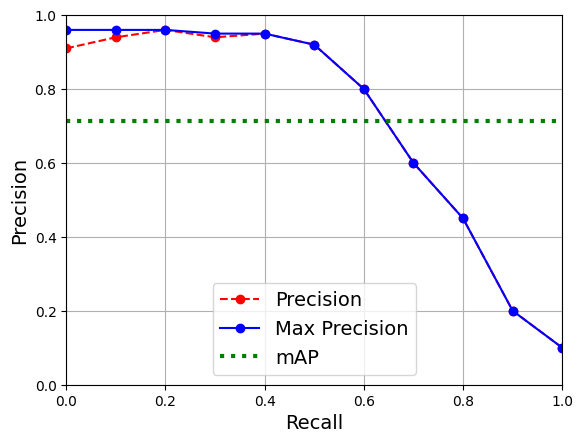

In [28]:
# Precision versus recall plot
recalls = np.linspace(0, 1, 11)

precisions = [0.91, 0.94, 0.96, 0.94, 0.95, 0.92, 0.80, 0.60, 0.45, 0.20, 0.10]
max_precisions = maximum_precisions(precisions)
# Definition of mAP
mAP = max_precisions.mean()
plt.plot(recalls, precisions, "ro--", label="Precision")
plt.plot(recalls, max_precisions, "bo-", label="Max Precision")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.plot([0, 1], [mAP, mAP], "g:", linewidth=3, label="mAP")
plt.grid(True)
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower center")
plt.show()

# Exercises

## 9. High Accuracy CNN for MNIST
_Exercise: Build your own CNN from scratch and try to achieve the highest possible accuracy on MNIST._

The following model uses 2 convolutional layers, followed by 1 pooling layer, then dropout 25%, then a dense layer, another dropout layer but with 50% dropout, and finally the output layer. It reaches about 99.2% accuracy on the test set. This places this model roughly in the top 20% in the [MNIST Kaggle competition](https://www.kaggle.com/c/digit-recognizer/) (if we ignore the models with an accuracy greater than 99.79% which were most likely trained on the test set, as explained by Chris Deotte in [this post](https://www.kaggle.com/c/digit-recognizer/discussion/61480)). Can you do better? To reach 99.5 to 99.7% accuracy on the test set, you need to add image augmentation, batch norm, use a learning schedule such as 1-cycle, and possibly create an ensemble.

In [29]:
mnist = tf.keras.datasets.mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = mnist
X_train_full = X_train_full / 255.
X_test = X_test / 255.
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [30]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, kernel_size=3, padding="same",
                           activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Conv2D(64, kernel_size=3, padding="same",
                           activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(128, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])

model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))
model.evaluate(X_test, y_test)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.8797 - loss: 0.3921 - val_accuracy: 0.9848 - val_loss: 0.0499
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9742 - loss: 0.0880 - val_accuracy: 0.9884 - val_loss: 0.0447
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9805 - loss: 0.0647 - val_accuracy: 0.9914 - val_loss: 0.0368
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9830 - loss: 0.0530 - val_accuracy: 0.9894 - val_loss: 0.0447
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9872 - loss: 0.0432 - val_accuracy: 0.9922 - val_loss: 0.0355
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9870 - loss: 0.0391 - val_accuracy: 0.9908 - val_loss: 0.0405
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9900 - loss: 0.0335 - val_accuracy: 0.9918 - val_loss: 0.0392
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9908 - loss: 0.028

[0.03372460976243019, 0.9916999936103821]

## 10.  Use transfer learning for large image classification

_Exercise: Use transfer learning for large image classification, going through these steps:_

* _Create a training set containing at least 100 images per class. For example, you could classify your own pictures based on the location (beach, mountain, city, etc.), or alternatively you can use an existing dataset (e.g., from TensorFlow Datasets)._
* _Split it into a training set, a validation set, and a test set._
* _Build the input pipeline, including the appropriate preprocessing operations, and optionally add data augmentation._
* _Fine-tune a pretrained model on this dataset._

See the Flowers example above.

In [31]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow 버전:", tf.__version__)

# --- 데이터셋 로드 및 분할 (TFDS 사용) ---
dataset_name = "tf_flowers"
# 데이터셋 로드 및 분할: 훈련 70%, 검증 15%, 테스트 15%
(ds_train_raw, ds_valid_raw, ds_test_raw), ds_info = tfds.load(
    dataset_name,
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'], # 데이터 분할 비율 지정
    with_info=True,       # 데이터셋 정보(ds_info) 함께 로드
    as_supervised=True,   # (이미지, 레이블) 튜플 형태로 반환
)

# 데이터셋 정보 가져오기
num_classes = ds_info.features['label'].num_classes
num_train_examples = tf.data.experimental.cardinality(ds_train_raw).numpy()
num_valid_examples = tf.data.experimental.cardinality(ds_valid_raw).numpy()
num_test_examples = tf.data.experimental.cardinality(ds_test_raw).numpy()

print(f"데이터셋: {dataset_name}")
print(f"클래스 수: {num_classes}")
print(f"훈련 샘플 수: {num_train_examples}")
print(f"검증 샘플 수: {num_valid_examples}")
print(f"테스트 샘플 수: {num_test_examples}")
print(f"클래스 이름: {ds_info.features['label'].names}")

TensorFlow 버전: 2.18.0
데이터셋: tf_flowers
클래스 수: 5
훈련 샘플 수: 2569
검증 샘플 수: 551
테스트 샘플 수: 550
클래스 이름: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


In [32]:
# --- 입력 파이프라인 구축 ---
IMG_SIZE = 224 # EfficientNetB0 (또는 다른 많은 모델)에서 요구하는 입력 크기
BATCH_SIZE = 32 # 메모리에 따라 조절
BUFFER_SIZE = 1000 # 셔플 버퍼 크기

# --- 전처리 함수 ---
# 선택한 기본 모델에 맞는 특정 전처리 함수 사용
preprocess_input = tf.keras.applications.efficientnet.preprocess_input

def preprocess(image, label):
  """이미지 크기 조정 및 모델별 전처리 적용"""
  image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE]) # 이미지 크기 조정
  image = preprocess_input(image) # 모델별 전처리 (예: 스케일링)
  return image, label

# --- 데이터 증강 레이어 ---
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),           # 무작위 좌우 반전
  tf.keras.layers.RandomRotation(0.2),                # 무작위 회전 (20%)
  tf.keras.layers.RandomZoom(0.1),                    # 무작위 확대/축소 (10%)
  tf.keras.layers.RandomContrast(0.1),                # 무작위 명암비 조절 (10%)
  # 필요시 더 많은 증강 기법 추가
], name="data_augmentation")

# --- 데이터셋에 적용 ---
# AUTOTUNE을 사용하여 병렬 처리 최적화
ds_train = ds_train_raw.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.cache() # 전처리 후 데이터 캐싱 (메모리나 로컬 디스크)
ds_train = ds_train.shuffle(BUFFER_SIZE) # 훈련 데이터 셔플
# 데이터 증강은 캐싱 및 셔플 *이후*, 훈련 세트에만 적용
ds_train = ds_train.map(lambda x, y: (data_augmentation(x, training=True), y),
                        num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.batch(BATCH_SIZE) # 배치 구성
ds_train = ds_train.prefetch(tf.data.AUTOTUNE) # 데이터 로딩과 모델 학습 중첩

# 검증 및 테스트 세트에는 증강을 적용하지 않음
ds_valid = ds_valid_raw.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds_valid = ds_valid.batch(BATCH_SIZE)
ds_valid = ds_valid.cache() # 검증 세트 캐싱
ds_valid = ds_valid.prefetch(tf.data.AUTOTUNE)

ds_test = ds_test_raw.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(BATCH_SIZE)
ds_test = ds_test.cache() # 테스트 세트 캐싱
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)


입력 파이프라인 구축 완료.


In [33]:
# --- 사전 훈련된 모델 미세 조정 ---

# --- 기본 모델 로드 ---
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

# EfficientNetB0 사용 - 정확도와 크기 간 균형이 좋음
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=IMG_SHAPE,
    include_top=False, # 최종 분류 레이어는 제외
    weights='imagenet' # ImageNet 사전 훈련 가중치 사용
)

# --- 기본 모델 동결 ---
base_model.trainable = False # 기본 모델의 가중치를 업데이트하지 않도록 설정
print(f"\n기본 모델 ({base_model.name}) 로드 완료.")
print(f"기본 모델의 레이어 수: {len(base_model.layers)}")

# --- 커스텀 헤드 추가 ---
inputs = tf.keras.Input(shape=IMG_SHAPE, name="input_layer")
# 참고: 기본 모델에 전처리 레이어가 포함될 수도 있지만, 여기서는 파이프라인에서 처리함
# 기본 모델이 특정 범위(예: [-1, 1])를 기대한다면 파이프라인 전처리와 일치해야 함.
# EfficientNet의 preprocess_input이 이 작업을 수행함.
x = base_model(inputs, training=False) # 중요: 동결 상태에서는 training=False로 호출
x = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x) # 특성 맵 평균 풀링
x = tf.keras.layers.Dropout(0.2, name="dropout_1")(x) # 규제를 위한 드롭아웃
outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name="output_layer")(x) # 최종 분류 레이어

model = tf.keras.Model(inputs, outputs)

model.summary() # 모델 구조 출력

# --- 초기 훈련 (헤드 훈련) ---
initial_epochs = 10 # 초기 훈련 에포크 수
# 새로운 헤드를 위한 약간 높은 학습률 설정
initial_lr = 0.001

# TFDS 레이블이 정수이므로 SparseCategoricalCrossentropy 사용
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

print(f"\n--- 초기 훈련 시작 (헤드 훈련) - {initial_epochs} 에포크 ---")
history = model.fit(ds_train,
                    epochs=initial_epochs,
                    validation_data=ds_valid)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

기본 모델 (efficientnetb0) 로드 완료.
기본 모델의 레이어 수: 238


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


--- 초기 훈련 시작 (헤드 훈련) - 10 에포크 ---
Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 90s 813ms/step - accuracy: 0.5240 - loss: 1.2137 - val_accuracy: 0.8494 - val_loss: 0.4902
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 33s 379ms/step - accuracy: 0.8395 - loss: 0.5034 - val_accuracy: 0.8711 - val_loss: 0.3688
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 39s 349ms/step - accuracy: 0.8746 - loss: 0.4170 - val_accuracy: 0.8784 - val_loss: 0.3115
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 42s 358ms/step - accuracy: 0.8966 - loss: 0.3393 - val_accuracy: 0.9038 - val_loss: 0.2813
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 39s 342ms/step - accuracy: 0.9043 - loss: 0.3064 - val_accuracy: 0.9038 - val_loss: 0.2669
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 28s 347ms/step - accuracy: 0.9079 - loss: 0.2884 - val_accuracy: 0.9111 - val_loss: 0.2558
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 28s 345ms/step - accuracy: 0.9118 - loss: 0.2618 - val_accuracy: 0.9129 - val_loss: 0.2442
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 41s 351ms/step - accurac

<ipython-input-35-c68d8d0fed33>:24: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 그래프 간격 조절
<ipython-input-35-c68d8d0fed33>:24: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 그래프 간격 조절
<ipython-input-35-c68d8d0fed33>:24: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 그래프 간격 조절
<ipython-input-35-c68d8d0fed33>:24: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 그래프 간격 조절
<ipython-input-35-c68d8d0fed33>:24: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 그래프 간격 조절
<ipython-input-35-c68d8d0fed33>:24: UserWarning: Glyph 54984 (\N{HANGUL SYLLABLE HUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 그래프 간격 조절
<ipython-input-35-c68d8d0fed33>:24: UserWarning: Glyph 47144 (\N{HANGUL SYLL

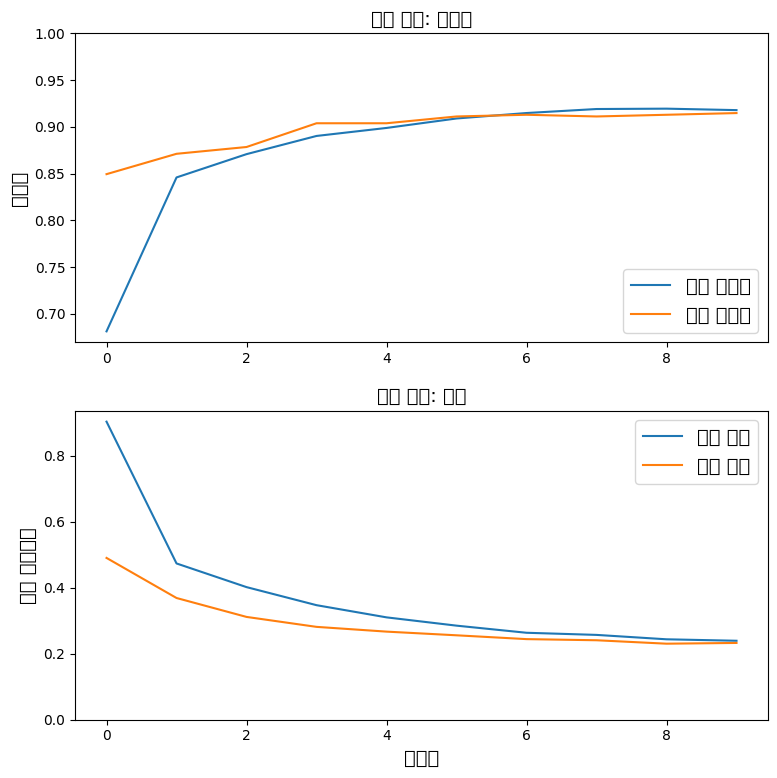

In [35]:
# --- 초기 훈련 결과 시각화 ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='훈련 정확도')
plt.plot(val_acc, label='검증 정확도')
plt.legend(loc='lower right')
plt.ylabel('정확도')
plt.ylim([min(plt.ylim()),1])
plt.title('초기 훈련: 정확도')

plt.subplot(2, 1, 2)
plt.plot(loss, label='훈련 손실')
plt.plot(val_loss, label='검증 손실')
plt.legend(loc='upper right')
plt.ylabel('교차 엔트로피')
plt.ylim([0,max(plt.ylim())])
plt.title('초기 훈련: 손실')
plt.xlabel('에포크')
plt.tight_layout() # 그래프 간격 조절
plt.show()


In [36]:
# --- 미세 조정 (Fine-tuning) ---
# 기본 모델의 일부 레이어 동결 해제

base_model.trainable = True # 전체 기본 모델을 훈련 가능하도록 설정

# 얼마나 많은 레이어를 동결 해제할 것인가? 상위 N개 레이어를 시도해 볼 수 있음.
# 개별 레이어보다 블록 단위로 동결 해제하는 것이 더 나을 수 있음.
# EfficientNetB0의 경우, 약 6번 또는 7번 블록 이후부터 동결 해제 시도 가능.
# 레이어 이름은 다를 수 있으므로 `base_model.layers`를 확인해야 할 수 있음.
# 예시로 상위 약 30개 레이어를 동결 해제
fine_tune_at_layer = len(base_model.layers) - 30 # 예시 값

print(f"\n기본 모델의 {fine_tune_at_layer}번째 레이어부터 동결 해제.")

# 지정된 지점 이전의 레이어들은 다시 동결
for layer in base_model.layers[:fine_tune_at_layer]:
  layer.trainable = False

# 지정된 지점 이후의 레이어들은 훈련 가능하게 설정 (단, BatchNormalization 제외)
for layer in base_model.layers[fine_tune_at_layer:]:
    # BatchNormalization 레이어는 미세 조정 중에는 동결 상태 유지 권장
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

# 미세 조정을 위해 모델을 **매우 낮은** 학습률로 다시 컴파일
fine_tune_lr = initial_lr / 100 # 예: 0.00001

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=fine_tune_lr), # 매우 낮은 학습률
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

model.summary() # 훈련 가능한 파라미터 수가 증가한 것을 확인
print(f"동결 해제 후 훈련 가능한 변수 수: {len(model.trainable_variables)}")

# 미세 조정 중 과적합 방지를 위한 조기 종료 콜백 추가
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',     # 검증 정확도 모니터링
    patience=5,                 # 5 에포크 동안 개선이 없으면 중지
    restore_best_weights=True   # 가장 좋았던 시점의 가중치 복원
)

fine_tune_epochs = 15 # 더 많은 에포크 동안 훈련하지만, 조기 종료에 의존
total_epochs = initial_epochs + fine_tune_epochs

print(f"\n--- 미세 조정 시작 - 최대 {fine_tune_epochs} 에포크 ---")
# 초기 훈련이 끝난 시점부터 이어서 훈련 (initial_epoch 설정)
history_fine = model.fit(ds_train,
                         epochs=total_epochs, # 총 에포크 수
                         initial_epoch=history.epoch[-1] + 1, # 이전 훈련 마지막 에포크 다음부터 시작
                         validation_data=ds_valid,
                         callbacks=[early_stopping]) # 조기 종료 콜백 사용


기본 모델의 208번째 레이어부터 동결 해제.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 1,489,765 (5.68 MB)

 Non-trainable params: 2,566,211 (9.79 MB)

동결 해제 후 훈련 가능한 변수 수: 16

--- 미세 조정 시작 - 최대 15 에포크 ---
Epoch 11/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 74s 601ms/step - accuracy: 0.9151 - loss: 0.2271 - val_accuracy: 0.9111 - val_loss: 0.2205
Epoch 12/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 353ms/step - accuracy: 0.9303 - loss: 0.2149 - val_accuracy: 0.9147 - val_loss: 0.2147
Epoch 13/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 30s 365ms/step - accuracy: 0.9250 - loss: 0.2022 - val_accuracy: 0.9147 - val_loss: 0.2089
Epoch 14/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 42s 372ms/step - accuracy: 0.9453 - loss: 0.1773 - val_accuracy: 0.9220 - val_loss: 0.2052
Epoch 15/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 44s 404ms/step - accuracy: 0.9294 - loss: 0.1875 - val_accuracy: 0.9201 - val_loss: 0.2000
Epoch 16/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 31s 382ms/step - accuracy: 0.9381 - loss: 0.1948 - val_accuracy: 0.9238 - val_loss: 0.1981
Epoch 17/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 33s 413ms/step - accuracy: 0.9487 - loss: 0.1557 - val_accuracy: 0.9220 - val_loss: 0.1949
Epoch 18/25
81/81 ━━━━━━━━━━━━━━━━━━

<ipython-input-38-9eb9516251e5>:27: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-38-9eb9516251e5>:27: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-38-9eb9516251e5>:27: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-38-9eb9516251e5>:27: UserWarning: Glyph 54984 (\N{HANGUL SYLLABLE HUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-38-9eb9516251e5>:27: UserWarning: Glyph 47144 (\N{HANGUL SYLLABLE RYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-38-9eb9516251e5>:27: UserWarning: Glyph 48143 (\N{HANGUL SYLLABLE MIC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-38-9eb9516251e5>:27: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<

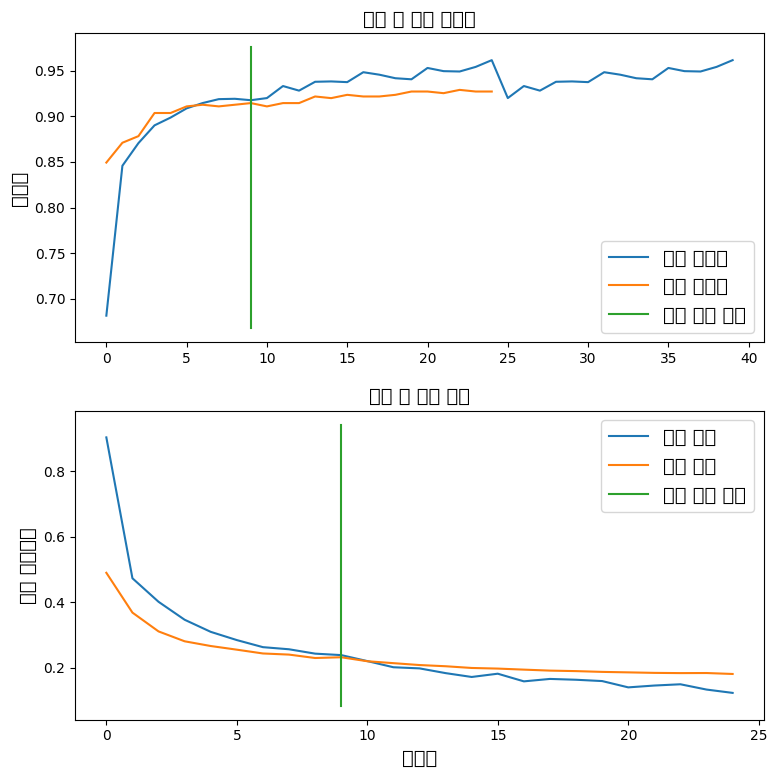

In [38]:
# --- 미세 조정 결과 시각화 ---
# history 객체에 결과 누적
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']
loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='훈련 정확도')
plt.plot(val_acc, label='검증 정확도')
plt.plot([initial_epochs-1, initial_epochs-1], plt.ylim(), label='미세 조정 시작') # 미세 조정 시작 지점 표시
plt.legend(loc='lower right')
plt.ylabel('정확도')
# plt.ylim([min(val_acc)-0.1, 1]) # 필요시 y축 범위 조절
plt.title('훈련 및 검증 정확도')

plt.subplot(2, 1, 2)
plt.plot(loss, label='훈련 손실')
plt.plot(val_loss, label='검증 손실')
plt.plot([initial_epochs-1, initial_epochs-1], plt.ylim(), label='미세 조정 시작') # 미세 조정 시작 지점 표시
plt.legend(loc='upper right')
plt.ylabel('교차 엔트로피')
# plt.ylim([0, max(loss)]) # 필요시 y축 범위 조절
plt.title('훈련 및 검증 손실')
plt.xlabel('에포크')
plt.tight_layout()
plt.show()


In [39]:
print("\n--- 테스트 세트 평가 ---")
loss, accuracy = model.evaluate(ds_test)
print(f'테스트 손실: {loss:.4f}')
print(f'테스트 정확도: {accuracy:.4f}')


--- 테스트 세트 평가 ---
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 332ms/step - accuracy: 0.9282 - loss: 0.2042
테스트 손실: 0.1659
테스트 정확도: 0.9400


## 11.
_Exercise: Go through TensorFlow's [Style Transfer tutorial](https://homl.info/styletuto). It is a fun way to generate art using Deep Learning._  
위의 tutorial 코드를 노트북에서 실행하여 결과를 제출.

신경 스타일 전송 튜토리얼 - 김민우

# 신경 스타일 전송

이번 튜토리얼에서는 딥 러닝을 사용하여 원하는 이미지를 다른 스타일의 이미지로 구성하는 법을 배워보겠습니다(피카소나 반 고흐처럼 그리기를 희망하나요?). 이 기법은 *Neural Style Transfer*로 알려져 있으며, Leon A. Gatys의 논문 [A Neural Algorithm of Artistic Style](https://arxiv.org/abs/1508.06576)에 잘 기술되어 있습니다.

참고: 이 튜토리얼은 원래 스타일 전송 알고리즘을 보여줍니다. 이는 이미지 콘텐츠를 특정 스타일로 최적화합니다. 최근의 접근 방식에서는 스타일화된 이미지를 직접 생성하도록 모델을 훈련합니다([CycleGAN](./cyclegan.ipynb)과 유사). 이 접근 방식은 훨씬 빠릅니다(최대 1000배).

[TensorFlow Hub](https://tfhub.dev)에서 사전 훈련된 모델을 사용하여 스타일 전송을 간단하게 적용하려면 [임의 이미지 스타일화 모델](https://www.tensorflow.org/hub/tutorials/tf2_arbitrary_image_stylization)을 사용하는 [임의 스타일에 대한 빠른 스타일 전송](https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2) 튜토리얼을 참조하세요. [TensorFlow Lite](https://www.tensorflow.org/lite)를 사용한 스타일 전송의 예는 [TensorFlow Lite를 사용한 예술적 스타일 전송](https://www.tensorflow.org/lite/examples/style_transfer/overview)을 참조하세요.

예를 들어, 이 개와 Wassily Kandinsky의 Composition 7의 이미지를 살펴보겠습니다.


<img src="https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg" class="">

([Yellow Labrador Looking](https://commons.wikimedia.org/wiki/File:YellowLabradorLooking_new.jpg), 출처: Wikimedia Commons, 저자: [Elf](https://en.wikipedia.org/wiki/User:Elf). 라이선스: [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en))


<img src="https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg" class="">

이제 Kandinsky가 이 스타일로만 이 개의 그림을 그리기로 결정했다면 어떤 모습이 될까요? 이렇지 않을까요?


<img src="https://tensorflow.org/tutorials/generative/images/stylized-image.png" class="">   

In [40]:
import os
import tensorflow as tf
# Load compressed models from tensorflow_hub
os.environ['TFHUB_MODEL_LOAD_FORMAT'] = 'COMPRESSED'

In [41]:
import IPython.display as display

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (12, 12)
mpl.rcParams['axes.grid'] = False

import numpy as np
import PIL.Image
import time
import functools

In [42]:
def tensor_to_image(tensor):
  tensor = tensor*255
  tensor = np.array(tensor, dtype=np.uint8)
  if np.ndim(tensor)>3:
    assert tensor.shape[0] == 1
    tensor = tensor[0]
  return PIL.Image.fromarray(tensor)

이미지를 다운로드받고 스타일 참조 이미지와 콘텐츠 이미지를 선택합니다:

In [43]:
content_path = tf.keras.utils.get_file('YellowLabradorLooking_new.jpg', 'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg')
style_path = tf.keras.utils.get_file('kandinsky5.jpg','https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')

83281/83281 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
195196/195196 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 입력 시각화

이미지를 불러오는 함수를 정의하고, 최대 이미지 크기를 512개의 픽셀로 제한합니다.

In [44]:
def load_img(path_to_img):
  max_dim = 512
  img = tf.io.read_file(path_to_img)
  img = tf.image.decode_image(img, channels=3)
  img = tf.image.convert_image_dtype(img, tf.float32)

  shape = tf.cast(tf.shape(img)[:-1], tf.float32)
  long_dim = max(shape)
  scale = max_dim / long_dim

  new_shape = tf.cast(shape * scale, tf.int32)

  img = tf.image.resize(img, new_shape)
  img = img[tf.newaxis, :]
  return img

이미지를 출력하기 위한 간단한 함수를 정의합니다:

In [45]:
def imshow(image, title=None):
  if len(image.shape) > 3:
    image = tf.squeeze(image, axis=0)

  plt.imshow(image)
  if title:
    plt.title(title)

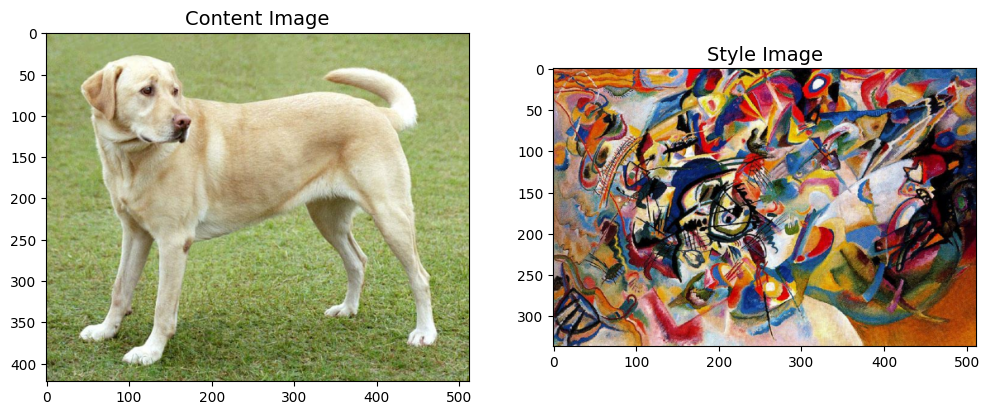

In [46]:
content_image = load_img(content_path)
style_image = load_img(style_path)

plt.subplot(1, 2, 1)
imshow(content_image, 'Content Image')

plt.subplot(1, 2, 2)
imshow(style_image, 'Style Image')

## TF-Hub를 통한 빠른 스타일 전이

이 튜토리얼은 이미지 콘텐츠를 특정 스타일로 최적화하는 원래 스타일 전송 알고리즘을 보여줍니다. 세부적으로 들어가기 전에[TensorFlow Hub 모델](https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2)이 이 작업을 어떻게 수행하는지 살펴보겠습니다.

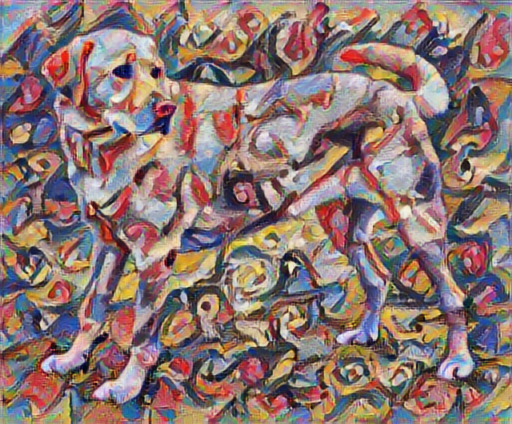

In [47]:
import tensorflow_hub as hub
hub_model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')
stylized_image = hub_model(tf.constant(content_image), tf.constant(style_image))[0]
tensor_to_image(stylized_image)

## 콘텐츠와 스타일 표현 정의하기

이미지의 콘텐츠와 스타일 표현(representation)을 얻기 위해, 모델의 몇 가지 중간층들을 살펴볼 것입니다. 모델의 입력층부터 시작해서, 처음 몇 개의 층은 선분이나 질감과 같은 이미지 내의 저차원적 특성에 반응합니다. 반면, 네트워크가 깊어지면 최종 몇 개의 층은 *바퀴*나 *눈*과 같은 고차원적 특성들을 나타냅니다. 이번 경우, 우리는 사전학습된 이미지 분류 네트워크인 VGG19 네트워크의 구조를 사용할 것입니다. 이 중간층들은 이미지에서 콘텐츠와 스타일 표현을 정의하는 데 필요합니다. 입력 이미지가 주어졌을때, 스타일 전이 알고리즘은 이 중간층들에서 콘텐츠와 스타일에 해당하는 타깃 표현들을 일치시키려고 시도할 것입니다.


[VGG19](https://keras.io/applications/#vgg19) 모델을 불러오고, 작동 여부를 확인하기 위해 이미지에 적용시켜봅시다:

In [48]:
x = tf.keras.applications.vgg19.preprocess_input(content_image*255)
x = tf.image.resize(x, (224, 224))
vgg = tf.keras.applications.VGG19(include_top=True, weights='imagenet')
prediction_probabilities = vgg(x)
prediction_probabilities.shape

574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


TensorShape([1, 1000])

In [49]:
predicted_top_5 = tf.keras.applications.vgg19.decode_predictions(prediction_probabilities.numpy())[0]
[(class_name, prob) for (number, class_name, prob) in predicted_top_5]

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[('Labrador_retriever', np.float32(0.49317107)),
 ('golden_retriever', np.float32(0.23665293)),
 ('kuvasz', np.float32(0.03635751)),
 ('Chesapeake_Bay_retriever', np.float32(0.024182767)),
 ('Greater_Swiss_Mountain_dog', np.float32(0.018646102))]

이제 분류층을 제외한 `VGG19` 모델을 불러오고, 각 층의 이름을 출력해봅니다.

In [50]:
vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')

print()
for layer in vgg.layers:
  print(layer.name)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

input_layer_4
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_conv4
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_conv4
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_conv4
block5_pool


이미지의 스타일과 콘텐츠를 나타내기 위한 모델의 중간층들을 선택합니다:


In [51]:
content_layers = ['block5_conv2']

style_layers = ['block1_conv1',
                'block2_conv1',
                'block3_conv1',
                'block4_conv1',
                'block5_conv1']

num_content_layers = len(content_layers)
num_style_layers = len(style_layers)

#### 스타일과 콘텐츠를 위한 중간층

그렇다면 사전훈련된 이미지 분류 네트워크 속에 있는 중간 출력으로 어떻게 스타일과 콘텐츠 표현을 정의할 수 있을까요?

고수준에서 보면 (네트워크의 훈련 목적인) 이미지 분류를 수행하기 위해서는 네트워크가 반드시 이미지를 이해햐야 합니다. 이는 미가공 이미지를 입력으로 받아 픽셀값들을 이미지 내에 존재하는 특성(feature)들에 대한 복합적인 이해로 변환할 수 있는 내부 표현(internal representation)을 만드는 작업이 포함됩니다.

또한 부분적으로 왜 합성곱(convolutional) 신경망의 일반화(generalize)가 쉽게 가능한지를 나타냅니다. 즉, 합성곱 신경망은 배경잡음(background noise)과 기타잡음(nuisances)에 상관없이 (고양이와 강아지와 같이)클래스 안에 있는 불변성(invariance)과 특징을 포착할 수 있습니다. 따라서 미가공 이미지의 입력과 분류 레이블(label)의 출력 중간 어딘가에서 모델은 복합 특성(complex feature) 추출기의 역할을 수행합니다. 그러므로, 모델의 중간층에 접근함으로써 입력 이미지의 콘텐츠와 스타일을 추출할 수 있습니다.

## 모델 만들기

`tf.keras.applications`에서 제공하는 모델들은 케라스 함수형 API을 통해 중간층에 쉽게 접근할 수 있도록 구성되어있습니다.

함수형 API를 이용해 모델을 정의하기 위해서는 모델의 입력과 출력을 지정합니다:

`model = Model(inputs, outputs)`

아래의 함수는 중간층들의 결과물을 배열 형태로 출력하는 `VGG19` 모델을 반환합니다:

In [52]:
def vgg_layers(layer_names):
  """ Creates a VGG model that returns a list of intermediate output values."""
  # Load our model. Load pretrained VGG, trained on ImageNet data
  vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
  vgg.trainable = False

  outputs = [vgg.get_layer(name).output for name in layer_names]

  model = tf.keras.Model([vgg.input], outputs)
  return model

In [53]:
style_extractor = vgg_layers(style_layers)
style_outputs = style_extractor(style_image*255)

#Look at the statistics of each layer's output
for name, output in zip(style_layers, style_outputs):
  print(name)
  print("  shape: ", output.numpy().shape)
  print("  min: ", output.numpy().min())
  print("  max: ", output.numpy().max())
  print("  mean: ", output.numpy().mean())
  print()

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_304']
Received: inputs=Tensor(shape=(1, 336, 512, 3))
  warnings.warn(msg)


block1_conv1
  shape:  (1, 336, 512, 64)
  min:  0.0
  max:  835.5256
  mean:  33.97525

block2_conv1
  shape:  (1, 168, 256, 128)
  min:  0.0
  max:  4625.8857
  mean:  199.82687

block3_conv1
  shape:  (1, 84, 128, 256)
  min:  0.0
  max:  8789.239
  mean:  230.78099

block4_conv1
  shape:  (1, 42, 64, 512)
  min:  0.0
  max:  21566.135
  mean:  791.24005

block5_conv1
  shape:  (1, 21, 32, 512)
  min:  0.0
  max:  3189.2542
  mean:  59.179478



## 스타일 계산하기

이미지의 콘텐츠는 중간층들의 특성 맵(feature map)의 값들로 표현됩니다.

이미지의 스타일은 각 특성 맵의 평균과 피쳐맵들 사이의 상관관계로 설명할 수 있습니다. 이런 정보를 담고 있는 그람 행렬(Gram matrix)은 각 위치에서 특성 벡터(feature vector)끼리의 외적을 구한 후,평균값을 냄으로써 구할 수 있습니다. 주어진 층에 대한 그람 행렬은 다음과 같이 계산할 수 있습니다:

이 식은 `tf.linalg.einsum` 함수를 통해 쉽게 계산할 수 있습니다:

`tf.linalg.einsum` 함수를 사용하여 이를 간결하게 구현할 수 있습니다.

In [54]:
def gram_matrix(input_tensor):
  result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
  input_shape = tf.shape(input_tensor)
  num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
  return result/(num_locations)

## 스타일과 콘텐츠 추출하기


스타일과 콘텐츠 텐서를 반환하는 모델을 만듭시다.

In [55]:
class StyleContentModel(tf.keras.models.Model):
  def __init__(self, style_layers, content_layers):
    super(StyleContentModel, self).__init__()
    self.vgg = vgg_layers(style_layers + content_layers)
    self.style_layers = style_layers
    self.content_layers = content_layers
    self.num_style_layers = len(style_layers)
    self.vgg.trainable = False

  def call(self, inputs):
    "Expects float input in [0,1]"
    inputs = inputs*255.0
    preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs)
    outputs = self.vgg(preprocessed_input)
    style_outputs, content_outputs = (outputs[:self.num_style_layers],
                                      outputs[self.num_style_layers:])

    style_outputs = [gram_matrix(style_output)
                     for style_output in style_outputs]

    content_dict = {content_name: value
                    for content_name, value
                    in zip(self.content_layers, content_outputs)}

    style_dict = {style_name: value
                  for style_name, value
                  in zip(self.style_layers, style_outputs)}

    return {'content': content_dict, 'style': style_dict}

In [56]:
extractor = StyleContentModel(style_layers, content_layers)

results = extractor(tf.constant(content_image))

print('Styles:')
for name, output in sorted(results['style'].items()):
  print("  ", name)
  print("    shape: ", output.numpy().shape)
  print("    min: ", output.numpy().min())
  print("    max: ", output.numpy().max())
  print("    mean: ", output.numpy().mean())
  print()

print("Contents:")
for name, output in sorted(results['content'].items()):
  print("  ", name)
  print("    shape: ", output.numpy().shape)
  print("    min: ", output.numpy().min())
  print("    max: ", output.numpy().max())
  print("    mean: ", output.numpy().mean())


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_326']
Received: inputs=Tensor(shape=(1, 422, 512, 3))
  warnings.warn(msg)


Styles:
   block1_conv1
    shape:  (1, 64, 64)
    min:  0.005522845
    max:  28014.555
    mean:  263.79022

   block2_conv1
    shape:  (1, 128, 128)
    min:  0.0
    max:  61479.484
    mean:  9100.949

   block3_conv1
    shape:  (1, 256, 256)
    min:  0.0
    max:  545623.44
    mean:  7660.976

   block4_conv1
    shape:  (1, 512, 512)
    min:  0.0
    max:  4320502.0
    mean:  134288.84

   block5_conv1
    shape:  (1, 512, 512)
    min:  0.0
    max:  110005.37
    mean:  1487.0378

Contents:
   block5_conv2
    shape:  (1, 26, 32, 512)
    min:  0.0
    max:  2410.8796
    mean:  13.764149


## 경사하강법 실행

이제 스타일과 콘텐츠 추출기를 사용해 스타일 전이 알고리즘을 구현할 차례입니다. 타깃에 대한 입력 이미지의 평균 제곱 오차를 계산한 후, 오차값들의 가중합을 구합니다.

스타일과 콘텐츠의 타깃값을 지정합니다:

In [57]:
style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_326']
Received: inputs=Tensor(shape=(1, 336, 512, 3))
  warnings.warn(msg)


최적화시킬 이미지를 담을 `tf.Variable`을 정의하고 콘텐츠 이미지로 초기화합니다. (이때 `tf.Variable`는 콘텐츠 이미지와 크기가 같아야 합니다.):

In [58]:
image = tf.Variable(content_image)

픽셀 값이 실수이므로 0과 1 사이로 클리핑하는 함수를 정의합니다:

---



In [59]:
def clip_0_1(image):
  return tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0)

옵티마이저를 생성합니다. 참조 연구에서는 LBFGS를 추천하지만, `Adam`도 충분히 적합합니다:

In [60]:
opt = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

In [61]:
style_weight=1e-2
content_weight=1e4

In [62]:
def style_content_loss(outputs):
    style_outputs = outputs['style']
    content_outputs = outputs['content']
    style_loss = tf.add_n([tf.reduce_mean((style_outputs[name]-style_targets[name])**2)
                           for name in style_outputs.keys()])
    style_loss *= style_weight / num_style_layers

    content_loss = tf.add_n([tf.reduce_mean((content_outputs[name]-content_targets[name])**2)
                             for name in content_outputs.keys()])
    content_loss *= content_weight / num_content_layers
    loss = style_loss + content_loss
    return loss

In [63]:
@tf.function()
def train_step(image):
  with tf.GradientTape() as tape:
    outputs = extractor(image)
    loss = style_content_loss(outputs)

  grad = tape.gradient(loss, image)
  opt.apply_gradients([(grad, image)])
  image.assign(clip_0_1(image))

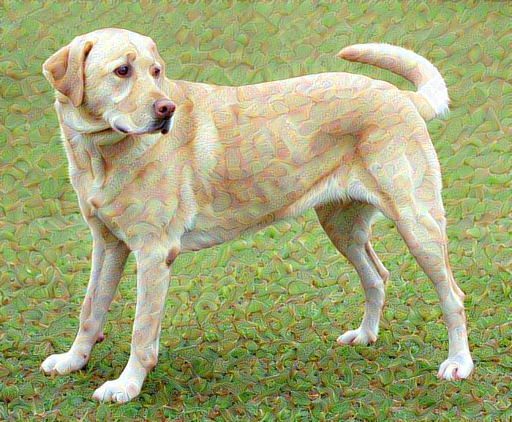

In [64]:
train_step(image)
train_step(image)
train_step(image)
tensor_to_image(image)

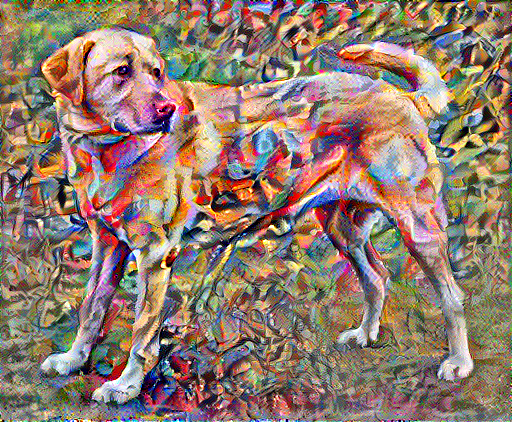

Train step: 1000
Total time: 72.3


In [65]:
import time
start = time.time()

epochs = 10
steps_per_epoch = 100

step = 0
for n in range(epochs):
  for m in range(steps_per_epoch):
    step += 1
    train_step(image)
    print(".", end='', flush=True)
  display.clear_output(wait=True)
  display.display(tensor_to_image(image))
  print("Train step: {}".format(step))

end = time.time()
print("Total time: {:.1f}".format(end-start))

## 총 변위 손실

이 기본 구현 방식의 한 가지 단점은 많은 고주파 아티팩(high frequency artifact)가 생겨난다는 점 입니다. 아티팩 생성을 줄이기 위해서는 이미지의 고주파 구성 요소에 대한 레귤러리제이션(regularization) 항을 추가해야 합니다. 스타일 전이에서는 이 변형된 오차값을 *총 변위 손실(total variation loss)*라고 합니다:

In [66]:
def high_pass_x_y(image):
  x_var = image[:, :, 1:, :] - image[:, :, :-1, :]
  y_var = image[:, 1:, :, :] - image[:, :-1, :, :]

  return x_var, y_var

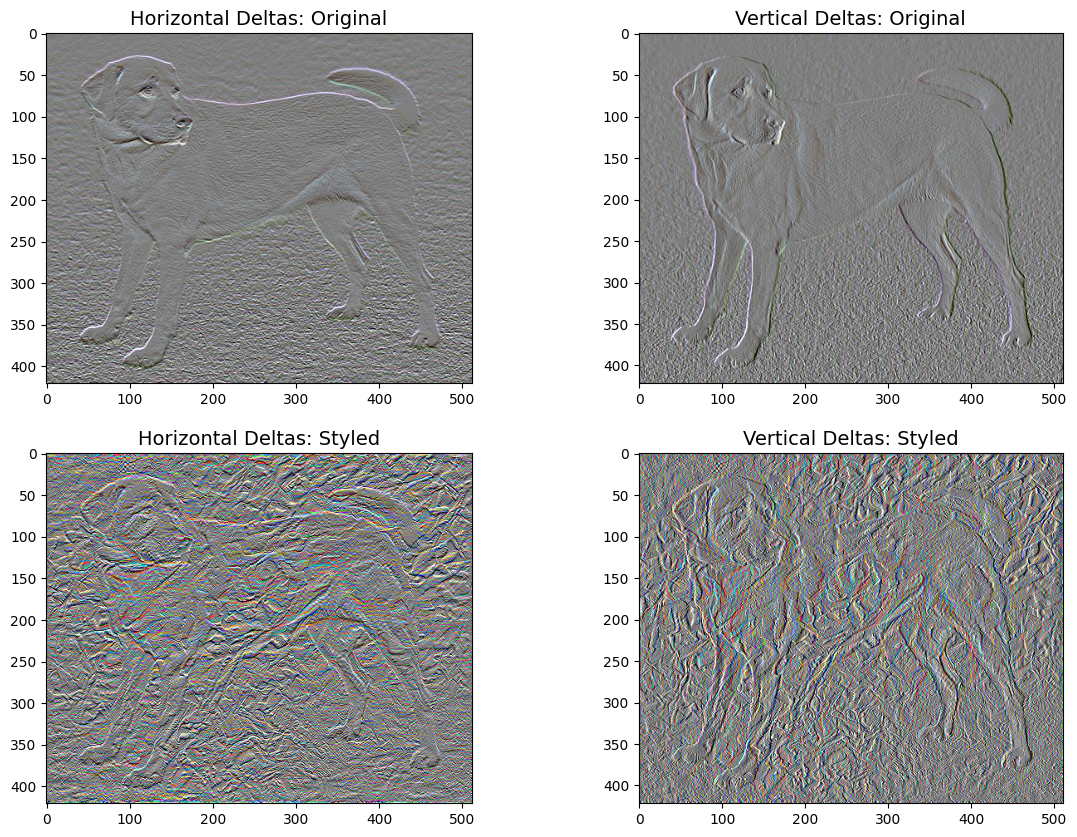

In [67]:
x_deltas, y_deltas = high_pass_x_y(content_image)

plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
imshow(clip_0_1(2*y_deltas+0.5), "Horizontal Deltas: Original")

plt.subplot(2, 2, 2)
imshow(clip_0_1(2*x_deltas+0.5), "Vertical Deltas: Original")

x_deltas, y_deltas = high_pass_x_y(image)

plt.subplot(2, 2, 3)
imshow(clip_0_1(2*y_deltas+0.5), "Horizontal Deltas: Styled")

plt.subplot(2, 2, 4)
imshow(clip_0_1(2*x_deltas+0.5), "Vertical Deltas: Styled")

위 이미지들은 고주파 구성 요소가 늘어났다는 것을 보여줍니다.

한 가지 흥미로운 사실은 고주파 구성 요소가 경계선 탐지기의 일종이라는 점입니다. 이를테면 소벨 경계선 탐지기(Sobel edge detector)를 사용하면 유사한 출력을 얻을 수 있습니다:

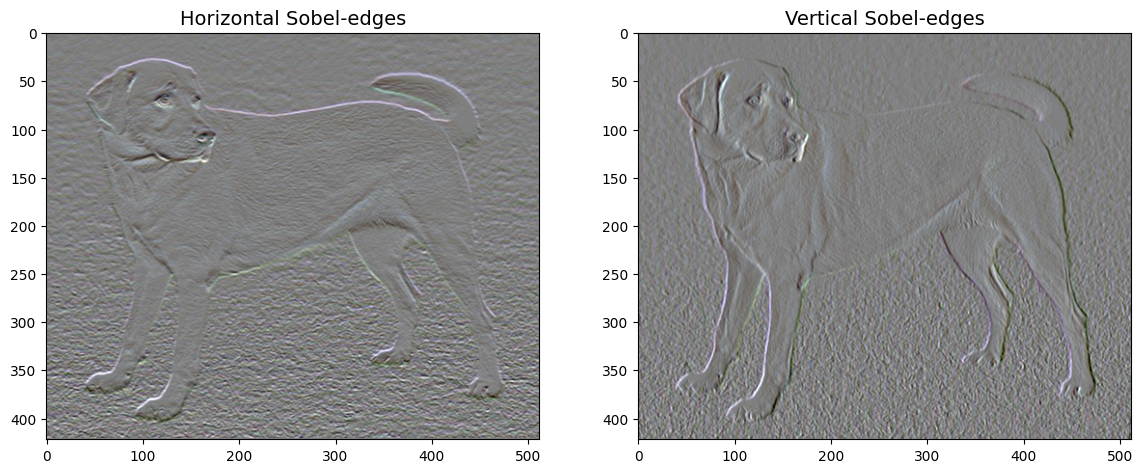

In [68]:
plt.figure(figsize=(14, 10))

sobel = tf.image.sobel_edges(content_image)
plt.subplot(1, 2, 1)
imshow(clip_0_1(sobel[..., 0]/4+0.5), "Horizontal Sobel-edges")
plt.subplot(1, 2, 2)
imshow(clip_0_1(sobel[..., 1]/4+0.5), "Vertical Sobel-edges")

In [69]:
def total_variation_loss(image):
  x_deltas, y_deltas = high_pass_x_y(image)
  return tf.reduce_sum(tf.abs(x_deltas)) + tf.reduce_sum(tf.abs(y_deltas))

In [70]:
total_variation_loss(image).numpy()

np.float32(149165.12)

식이 잘 계산된다는 것을 확인할 수 있습니다. 하지만 다행히도 텐서플로에는 이미 표준 함수가 내장되어 있기 직접 오차식을 구현할 필요는 없습니다:

In [71]:
tf.image.total_variation(image).numpy()

array([149165.12], dtype=float32)

## 다시 최적화하기

`total_variation_loss`를 위한 가중치를 정의합니다:

In [72]:
total_variation_weight=30

이제 이 가중치를 `train_step` 함수에서 사용합니다:

In [73]:
@tf.function()
def train_step(image):
  with tf.GradientTape() as tape:
    outputs = extractor(image)
    loss = style_content_loss(outputs)
    loss += total_variation_weight*tf.image.total_variation(image)

  grad = tape.gradient(loss, image)
  opt.apply_gradients([(grad, image)])
  image.assign(clip_0_1(image))

이미지 변수와 옵티마이저를 다시 초기화합니다.

In [74]:
opt = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)
image = tf.Variable(content_image)

최적화를 수행합니다:

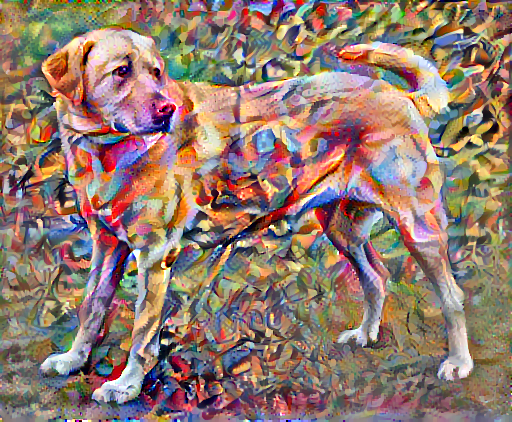

Train step: 1000
Total time: 76.6


In [75]:
import time
start = time.time()

epochs = 10
steps_per_epoch = 100

step = 0
for n in range(epochs):
  for m in range(steps_per_epoch):
    step += 1
    train_step(image)
    print(".", end='', flush=True)
  display.clear_output(wait=True)
  display.display(tensor_to_image(image))
  print("Train step: {}".format(step))

end = time.time()
print("Total time: {:.1f}".format(end-start))

마지막으로, 결과물을 저장합니다:

In [76]:
file_name = 'stylized-image.png'
tensor_to_image(image).save(file_name)

try:
  from google.colab import files
except ImportError:
   pass
else:
  files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

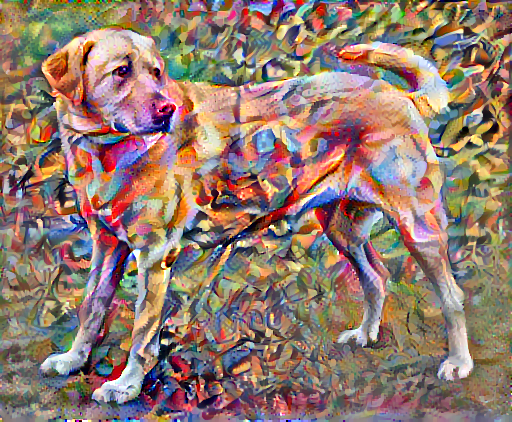